In [3]:
import re
# best models: offline random forest / or combine random forest
import numpy as np
from IPython.core.pylabtools import figsize
from fontTools.misc.plistlib import end_key
from joblib.testing import param

import utils
import matplotlib as mpl
import params
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import os
import joblib
def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None

bg_col_dict = params.bg_col_dict
fb_cols = params.fb_vars
bg_cols = params.bg_cols
model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}


In [4]:
latest_contrl = False
missing_contrl = True
del_country_contrl = False


In [4]:
# import models 
model_dict = {}
for model_type in ['offline', 'combined', 'online']:
    model_dict[model_type] = {}
    for indicator in ['internet', 'mobile']:
        model_dict[model_type][indicator] = {}
        for outcome_var in ['ggi','wom','men']:
            model_filename =f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
            #model_filename = f'{indicator}_{model_type}_{outcome_var}_full_model.pkl'
            
            model_filepath = params.dropbox_data_path.parent / 'models/rf' / model_filename
            model_dict[model_type][indicator][outcome_var]= load_model(model_filepath)


## feature importance of the original models

In [29]:
# visualize feature importance for combined models， only show the top 20 featurex for each model
top_feature_dict = {}

for indicator in ['internet', 'mobile']:
    for model_type in ['offline', 'combined', 'online']:
        # top_feature_dict[indicator] = {}
        for outcome_var in ['ggi','wom','men']:
            model = model_dict[model_type][indicator][outcome_var]
            if model is None:
                continue
            feature_importance = model.feature_importances_
            features = model.feature_names_in_
            feature_importance = 100.0 * (feature_importance / feature_importance.max())
            
            sorted_idx = np.argsort(feature_importance)[::-1]
            pos = np.arange(sorted_idx.shape[0]) + .5
            pos = pos[0:20]
            """
             
            plt.figure(figsize=(5, 8))
            plt.barh(pos, feature_importance[sorted_idx][0:20], align='center')
            plt.yticks(pos, [bg_col_dict[x] if x in bg_col_dict.keys() else x for x in features[sorted_idx][0:20]])
            plt.xlabel('Relative Importance')
            plt.title(f'{indicator} {model_type} {outcome_var} Feature Importance')
            # plt.show()
            """

            top_feature_dict[f'{indicator}_{model_type}_{outcome_var}'] =  list(features[sorted_idx][0:len([x for x in feature_importance if x>20])])
""" 
for key in top_feature_dict.keys():
    print(key)
    print(', '.join(top_feature_dict[key]))
    print('-----------------------------------')
"""

" \nfor key in top_feature_dict.keys():\n    print(key)\n    print(', '.join(top_feature_dict[key]))\n    print('-----------------------------------')\n"

In [36]:
# former pipeline specifications 
former_model_specs = {'mobile_online_ggi':['fb_18_999_r'],
               'mobile_online_wom':['fb_18_999_wom'],
               'mobile_online_men':['fb_18_999_men'],
               
               'mobile_offline_ggi':['wdi_litrad','wdi_unempr','le','gggi_eas','gdp_pcap'],
               'mobile_offline_wom':['wdi_litrad','wdi_unempr','le','gggi_eas','gdp_pcap'],
               'mobile_offline_men':['wdi_litrad','wdi_unempr','le','gggi_eas','gdp_pcap'],
               
                'mobile_combined_ggi':['gggi_eas','gggi_ggi','fb_25_29_r','fb_android_device_users_r','fb_21_999_r'],
               'mobile_combined_wom':['gggi_eas','gggi_ggi','fb_25_29_wom','fb_android_device_users_wom','fb_21_999_wom'],
               'mobile_combined_men':['gggi_eas','gggi_ggi','fb_25_29_men','fb_android_device_users_men','fb_21_999_men'],
               
                'internet_online_ggi':['fb_18_999_r'],
                'internet_online_wom':['fb_18_999_wom'],
               'internet_online_men':['fb_18_999_men'],
               
                'internet_offline_ggi':['gggi_eas','gdp_pcap','le','wdi_internet','educ_hdi_r'],
               'internet_offline_wom':['gggi_eas','gdp_pcap','le','wdi_internet','educ_hdi_r'],
               'internet_offline_men':['gggi_eas','gdp_pcap','le','wdi_internet','educ_hdi_r'],
               
                'internet_combined_ggi':['wdi_gert','gdp_pcap','fb_18_999_r','fb_18_23_r','fb_20_64_r'],
                'internet_combined_wom':['wdi_gert','gdp_pcap','fb_18_999_wom','fb_18_23_wom','fb_20_64_wom'],
                'internet_combined_men':['wdi_gert','gdp_pcap','fb_18_999_men','fb_18_23_men','fb_20_64_men']}

# all different specifications 

In [6]:
from national.data_refresh.src import utils
from national.data_refresh.src import params
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import os
import joblib

# Initialize an empty DataFrame to store the results

fb_cols = params.fb_vars
bg_cols = params.bg_cols
model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}

# dataset = "combined_multiple_years_no_missing_fb_aligned.csv"
dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
def extract_info_from_filename(filename):
    if "no_missing" in filename:
        missing_imputed = True
    else:
        missing_imputed = False

    year = filename.split('_')[-1].split('-')[0]
    return missing_imputed, year


def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    return data


def save_model(model, file_path):
    joblib.dump(model, file_path)


def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None


def evaluate_random_forest_leave_one_out(indicator, dataset, model_type, country_specific_df, year_specific_df, continent_specific_df, outcome_var,models='rf'):
    # Load the dataset
    data = pd.read_csv(data_path / dataset)
    model_spec = model_specs[model_type]
    print(indicator,model_type,model_spec)

    # Drop rows where the target variable is missing
    data = data.dropna(subset=[f'{outcome_var}']+model_spec)
    data.rename(columns={f'{indicator}_year':'year'}, inplace=True)

    # Preprocess data
    # conti_cols = [f'conti_{conti}' for conti in ['Asia', 'Africa', 'Europe', 'South America', 'North America', 'Oceania']]
    
    X = data[model_spec]
    #if any(conti_cols) in model_spec:
    #    cols = [x for x in model_spec if 'conti' in x]
    #    for col in cols:
    #        X[col] = [0]*len(X)
    
    y = data[outcome_var]

    # Check if a model for this specific validation already exists
    model_filename = f'{model_type}_{outcome_var}_full_model.pkl'
    model_filepath = params.dropbox_data_path.parent / f'models/{models}' / model_filename
    if not os.path.exists(params.dropbox_data_path.parent / f'models/{models}'):
        os.mkdir(params.dropbox_data_path.parent / f'models/{models}')

    # Try to load the model if it exists
    rf_loo = load_model(model_filepath)

    # If no model exists, train a new one
    if rf_loo is None:
        rf_loo = RandomForestRegressor(random_state=42)
        rf_loo.fit(X, y)
        save_model(rf_loo, model_filepath)

    y_pred_full = rf_loo.predict(X)
    r2_full_sample = r2_score(y, y_pred_full)


    # leave one out validation
    def leave_one_column_out(column):
        recorder = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', column, 'pred', 'true', 'train_size'])
        for unique_value in data[column].unique():
            X_train_loo = X[data[column] != unique_value]
            y_train_loo = y[data[column] != unique_value]

            X_test_loo = X[data[column] == unique_value]
            y_test_loo = y[data[column] == unique_value]

            # Check if a model for this specific validation already exists
            model_filename = f'{model_type}_{outcome_var}_{column}_{unique_value}_model.pkl'
            model_filepath = params.dropbox_data_path.parent / f'models/{models}' / model_filename

            # Try to load the model if it exists
            rf_loo = load_model(model_filepath)

            # If no model exists, train a new one
            if rf_loo is None:
                rf_loo = RandomForestRegressor(random_state=42)
                rf_loo.fit(X_train_loo, y_train_loo)
                save_model(rf_loo, model_filepath)

            y_pred_loo = rf_loo.predict(X_test_loo)
            for i in range(len(y_pred_loo)):
                recorder.loc[len(recorder)] = [f'{indicator} {model_type}', outcome_var, model_type, unique_value, y_pred_loo[i], y_test_loo.values[i], len(y_train_loo)]

        r2 = r2_score(recorder['true'], recorder['pred'])
        return recorder, r2

    r2s = {}
    for leave_column in ['country', 'year', 'conti']:
        temp, r2s[leave_column] = leave_one_column_out(leave_column)
        if leave_column == 'country':
            country_specific_df = pd.concat([country_specific_df, temp], axis=0)
        elif leave_column == 'year':
            year_specific_df = pd.concat([year_specific_df, temp], axis=0)
        # else:
        #     continent_specific_df = pd.concat([continent_specific_df,temp], axis=0)

    # ----------------------------------------
    # Append the results to the main DataFrame
    results_df.loc[len(results_df)] = {
        "model_name": f'{indicator} {model_type}',
        'method': models,
        'outcome_var': outcome_var,
        "model_type": model_type,
        'best_r2': r2_full_sample,
        'loco_r2': r2s['country'],
        'loyo_r2': r2s['year'],
        # 'loconto_r2':r2s['conti'],
        'selected_var': ''
    }

    return year_specific_df, country_specific_df, continent_specific_df, results_df




## running the models 

In [7]:
#type = '_paired_levels'
#type = '_18_plus'
#type = '_aggregate'
# type = '_top_features'
#type = '_rf'
#type = '_former_models'
#type = '_18_plus_paried_levels'
# type = '_aggregate_paried_levels'
#type = '18_plus_paired_no_conti'
#type = 'aggregate_paired_no_conti'
# "top_features"

# 'top_features','former_models','paired_levels','18_plus','aggregate','rf',
for type in ['18_plus']:
    
    model_specs = {'online': fb_cols, 'offline': bg_cols, 'combined': fb_cols + bg_cols}
    results_df = pd.DataFrame(columns=['model_name', 'method', 'outcome_var', 'model_type', 'best_adj_r2', 'best_r2', 'loco_r2', 'loyo_r2','loconto_r2','selected_var'])
    country_specific_df = pd.DataFrame(columns=["name",'outcome_var','model_type','country','pred','true','train_size'])
    year_specific_df = pd.DataFrame(columns=["name",'outcome_var','model_type','year','pred','true','train_size'])
    continent_specific_df = pd.DataFrame(columns=["name",'outcome_var','model_type','conti','pred','true','train_size'])

    print("=====================================")
    print(type)
    print("=====================================")
    # Loop through each dataset and evaluate the model using leave-one-country-out validation
    for indicator in ['internet', 'mobile']:
        data_path = params.dropbox_data_path / f"combined_data/{indicator}"
        for model_type in ['online', 'offline', 'combined']:
            for outcome_var in [f'{indicator}_ggi', f'{indicator}_wom', f'{indicator}_men']:
                level = outcome_var.split('_')[-1]
                
                if type == 'paired_levels':
                    if model_type != 'offline':
                        if level =='ggi':
                            model_specs[f"{indicator}_{model_type}_{level}"] =list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if '_r' in x]
                        else:
                            model_specs[f"{indicator}_{model_type}_{level}"] = list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if level in x]
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                    
    
                elif type == 'top_features':
                    model_specs = top_feature_dict
                elif type == 'former_models':
                    model_specs = former_model_specs
                
                elif type == '18_plus':
                    if model_type != 'offline':
                        model_specs[f"{indicator}_{model_type}_{level}"] = list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if '18_999' in x]
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                
                elif type == '18_plus_paired_levels':
                    if model_type != 'offline':
                        if level =='ggi':
                            model_specs[f"{indicator}_{model_type}_{level}"] =list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if '18_999_r' in x]
                        else:
                            model_specs[f"{indicator}_{model_type}_{level}"] = list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if f'18_999_{level}' in x]
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                
                elif type == '18_plus_paired_no_conti':
                    if model_type != 'offline':
                        if level =='ggi':
                            model_specs[f"{indicator}_{model_type}_{level}"] =list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if '18_999_r' in x]
                        else:
                            model_specs[f"{indicator}_{model_type}_{level}"] = list(set(model_specs[model_type])-set(fb_cols))+[x for x in fb_cols  if f'18_999_{level}' in x]
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                        
                
                elif type == 'aggregate_paired_levels':
                    if model_type != 'offline':
                        aggregate_ages = ['18_999','25_49','50_999']
                        if level == 'ggi':
                            model_specs[f"{indicator}_{model_type}_{level}"] = (list(set(model_specs[model_type])-set(fb_cols))+
                                                                [x for x in fb_cols  if any(f'{aggregate_age}_r' in x for aggregate_age in aggregate_ages)])
                        else:
                            model_specs[f"{indicator}_{model_type}_{level}"] = (list(set(model_specs[model_type])-set(fb_cols))+
                                                                [x for x in fb_cols  if any(f'{aggregate_age}_{level}' in x for aggregate_age in aggregate_ages)])
                        
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                
                elif type =='aggregate_paired_no_conti':
                    if model_type != 'offline':
                        aggregate_ages = ['18_999','25_49','50_999']
                        if level == 'ggi':
                            model_specs[f"{indicator}_{model_type}_{level}"] = (list(set(model_specs[model_type])-set(fb_cols))+
                                                                [x for x in fb_cols  if any(f'{aggregate_age}_r' in x for aggregate_age in aggregate_ages)])
                        else:
                            model_specs[f"{indicator}_{model_type}_{level}"] = (list(set(model_specs[model_type])-set(fb_cols))+
                                                                [x for x in fb_cols  if any(f'{aggregate_age}_{level}' in x for aggregate_age in aggregate_ages)])
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                
                elif type == 'aggregate':
                    if model_type != 'offline':
                        aggregate_ages = ['18_999','25_49','50_999']
                        model_specs[f"{indicator}_{model_type}_{level}"] = (list(set(model_specs[model_type])-set(fb_cols))+
                                                                [x for x in fb_cols  if any(aggregate_age in x for aggregate_age in aggregate_ages)])
                    else:
                        model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
                elif type =='rf':
                    model_specs[f"{indicator}_{model_type}_{level}"] = model_specs[model_type]
            
                
                year_specific_df, country_specific_df, continent_specific_df, results_df = evaluate_random_forest_leave_one_out(indicator, dataset, f"{indicator}_{model_type}_{level}", country_specific_df, year_specific_df, continent_specific_df, outcome_var,type)
    
    country_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest_loco_results_{type}.csv', index=False)
    year_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest_loyo_results_{type}.csv', index=False)
    continent_specific_df.to_csv(params.dropbox_data_path.parent/f'files/logs/random_forest_loconto_results_{type}.csv', index=False)
    results_df.to_csv(params.dropbox_data_path.parent/f'results/rf/random_forest_results_summary_{type}.csv', index=False)

18_plus
internet internet_online_ggi ['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
internet internet_online_wom ['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
internet internet_online_men ['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
internet internet_offline_ggi ['abr', 'bicc_gmi', 'coef_ineq', 'eys', 'eys_r', 'gdi', 'gdp_pcap', 'gggi_eas', 'gggi_ggi', 'gggi_hss', 'gggi_pes', 'gggi_pos', 'gii', 'gni_pc', 'gni_pc_r', 'hcpi_a', 'hdi', 'hdi_r', 'ihdi', 'ineq_edu', 'ineq_inc', 'ineq_le', 'le', 'le_r', 'lfpr_r', 'mmr', 'mys', 'mys_r', 'pov_hr', 'se_r', 'une_girlglsr', 'une_girlglst', 'une_girlgpr', 'une_girlgpt', 'vdem_gender', 'wbgi_pve', 'wdi_acel', 'wdi_fertility', 'wdi_gert', 'wdi_gertr', 'wdi_litrad', 'wdi_litradr', 'pr_r', 'wdi_unemp', 'wdi_unempr', 'wdi_internet', 'educ_hdi_r']
internet internet_offline_wom ['abr', 'bicc_gmi', 'coef_ineq', 'eys', 'eys_r', 'gdi', 'gdp_pcap', 'gggi_eas', 'gggi_ggi', 'gggi_hss', 'gggi_pes', 'gggi_pos', 'gii', 'gni_pc', 'gni_pc_r', 'hcpi_a', 

## old specifications

In [ ]:
    
for indicator in ['internet', 'mobile']:
    
    
    # compare results_df and results_df_original(with the imputation)
    df_res = pd.DataFrame()
    type_dict = {'rf':'rf',
                 'paired_levels':'rf \n paired levels',
                 '18_plus':'rf \n18 plus',
                 'top_features':'rf \n top features',
                 'aggregate':'rf \n aggregate',
                 'former_models':'rf \n former specs',
                 '18_plus_paired_levels':'rf \n 18 plus \n paired',
                 'aggregate_paired_levels':'rf \n aggregate \n paired'
                 #'aggregate_paired_no_conti': 'aggregate\n paired\n no conti',
                 #'18_plus_paired_no_conti': '18 plus\n paired\n no conti'
                 } #,
    
    keywords = ['online', 'offline', 'combined']
    
    for type in type_dict.keys():
        temp = pd.read_csv(params.dropbox_data_path.parent/f'results/rf/random_forest_results_summary_{type}.csv')
        temp['method'] = [type_dict[type]] * len(temp)
        pattern =  '|'.join(keywords) 
        temp['model_type'] = temp['model_type'].str.findall(pattern).str.join(' ')
    
        df_res = pd.concat([df_res,temp],axis=0)
    
    
    
    colors = params.colors
    
    
    # Grouping by outcome_var
    grouped = df_res.loc[df_res['outcome_var'].str.contains(indicator)].groupby(['outcome_var', 'model_type'])
    
    # Creating subplots
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(23, 11))
    # set the portion of first column of subplots to be 0.4
    
    
    axes = axes.flatten()
    count = 0
    
    for ((outcome_var, model_type), group), ax in zip(grouped, axes):
        #group['method'] = pd.Categorical(group['method'], categories=['on',], ordered=True)
    
        # group = group.sort_values(by='method')  # Sorting by model_type within each outcome_var
        custom_dict = {x: i for x, i in zip(['rf', 'rf \n former specs', 'rf \n top features', 'rf \n paired levels', 
                                             'rf \n18 plus', 'rf \n 18 plus \n paired',
                                             'rf \n aggregate', 'rf \n aggregate \n paired'], range(len(type_dict)))}
        group=group.sort_values(by='method',key=lambda x: x.map(custom_dict))
        # Defining the position for each bar
        bar_width = 0.25  # Width of each bar
        x = range(len(group['method']))
    
        # Plotting the bars
        bars1 = ax.bar([pos - bar_width for pos in x], group['loco_r2'], width=bar_width, align='center', label='LOCO R2', color=colors['blue'])
        bars2 = ax.bar(x, group['loyo_r2'], width=bar_width, align='center', label='LOYO R2', color=colors['red'])
        bars3 = ax.bar([pos + bar_width for pos in x], group['best_r2'], width=bar_width, align='center', label='Best R2', color=colors['peach'])
    
        # Adding the values
        for bars in [bars1, bars2, bars3]:  #, bars3]:
            for bar in bars:
                yval = round(bar.get_height(), 2)
                ax.text(bar.get_x() + bar.get_width() / 2, yval, yval, ha='center', va='bottom', fontsize=9)
    
        # Add legend on the bottom plot
        if count == 7:
            ax.legend(bbox_to_anchor=(0.5, -0.4), loc='lower center', ncol=3)
    
        # Set title, labels, and grid
        ax.set_title(f"{model_type}")
        ax.set_xticks(x)
    
        #if count % 3 != 1:
        ax.set_xticklabels(group['method'])
        #else:
        #    ax.set_xticklabels([f'{x}' for x in zip(group['method'])])
    
        # Remove all spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
    
        # Keep the y-axis spine only for the leftmost plots
        if count % 3 == 0:  # First column in each row
            ax.spines['left'].set_visible(True)
            ax.set_ylabel(f"{outcome_var.replace('_', ' ').replace(indicator, '')}\nR2")
        else:
            ax.set_yticks([])  # Remove y-axis ticks for other plots
    
        ax.grid(axis='both', linestyle='--', alpha=0)
        # ax.yaxis.grid(True)
    
        count += 1
    
    # Adjust layout and show the plot
    fig.suptitle(f'{indicator}', fontsize=18)
    plt.tight_layout()
    plt.savefig(params.dropbox_data_path.parent/f'graphs/result_check/random_forest_results_compare_{indicator}.pdf')


# SHAP values

internet offline ['abr' 'bicc_gmi' 'coef_ineq' 'eys' 'eys_r' 'gdi' 'gdp_pcap' 'gggi_eas'
 'gggi_ggi' 'gggi_hss' 'gggi_pes' 'gggi_pos' 'gii' 'gni_pc' 'gni_pc_r'
 'hcpi_a' 'hdi' 'hdi_r' 'ihdi' 'ineq_edu' 'ineq_inc' 'ineq_le' 'le' 'le_r'
 'lfpr_r' 'mmr' 'mys' 'mys_r' 'pov_hr' 'se_r' 'une_girlglsr'
 'une_girlglst' 'une_girlgpr' 'une_girlgpt' 'vdem_gender' 'wbgi_pve'
 'wdi_acel' 'wdi_fertility' 'wdi_gert' 'wdi_gertr' 'wdi_litrad'
 'wdi_litradr' 'pr_r' 'wdi_unemp' 'wdi_unempr' 'wdi_internet' 'educ_hdi_r']
internet offline ['abr' 'bicc_gmi' 'coef_ineq' 'eys' 'eys_r' 'gdi' 'gdp_pcap' 'gggi_eas'
 'gggi_ggi' 'gggi_hss' 'gggi_pes' 'gggi_pos' 'gii' 'gni_pc' 'gni_pc_r'
 'hcpi_a' 'hdi' 'hdi_r' 'ihdi' 'ineq_edu' 'ineq_inc' 'ineq_le' 'le' 'le_r'
 'lfpr_r' 'mmr' 'mys' 'mys_r' 'pov_hr' 'se_r' 'une_girlglsr'
 'une_girlglst' 'une_girlgpr' 'une_girlgpt' 'vdem_gender' 'wbgi_pve'
 'wdi_acel' 'wdi_fertility' 'wdi_gert' 'wdi_gertr' 'wdi_litrad'
 'wdi_litradr' 'pr_r' 'wdi_unemp' 'wdi_unempr' 'wdi_internet' 'edu

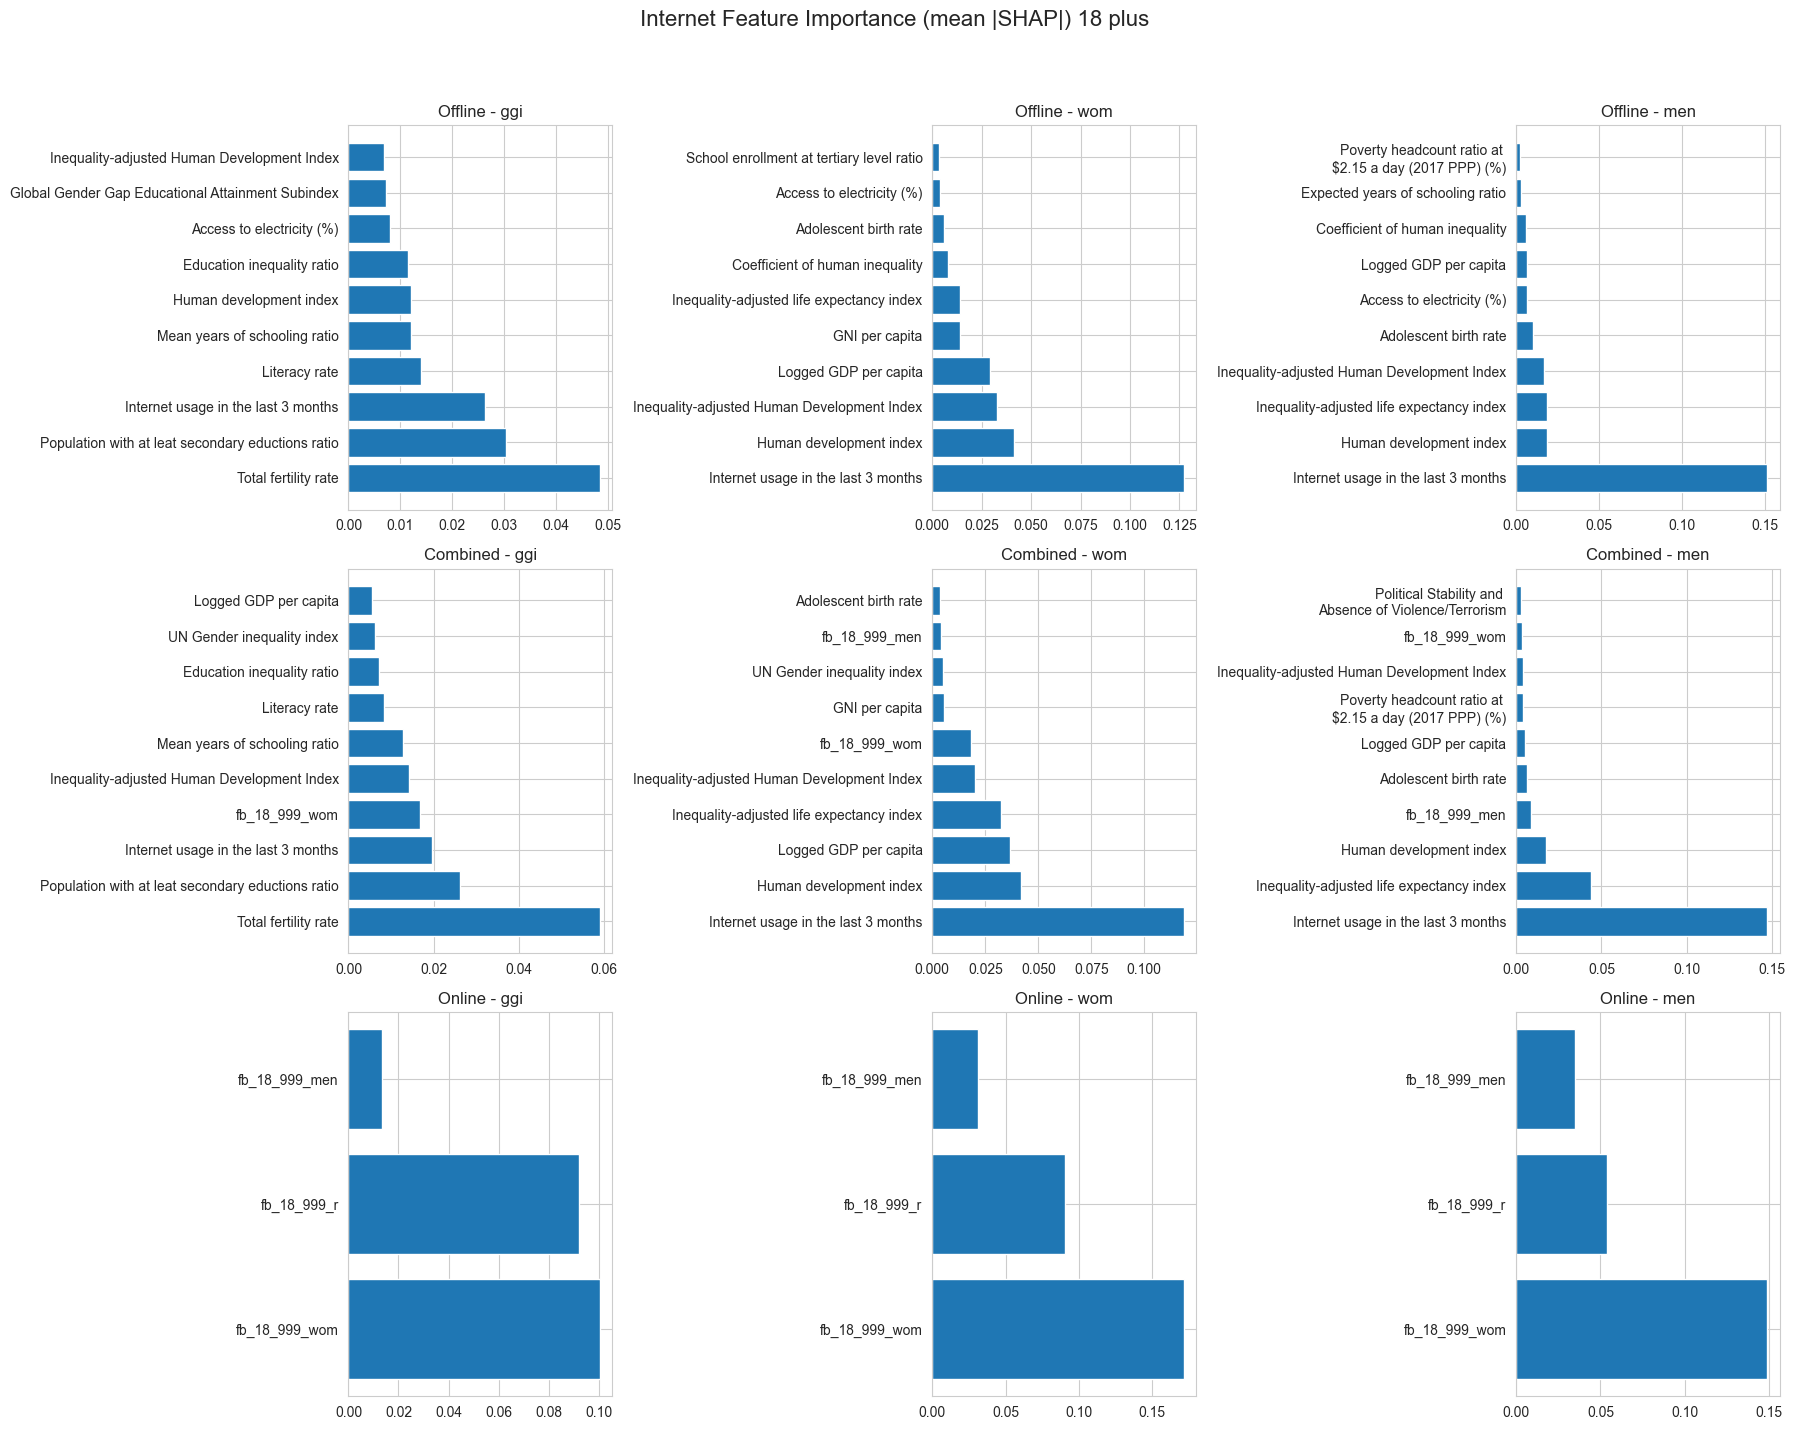

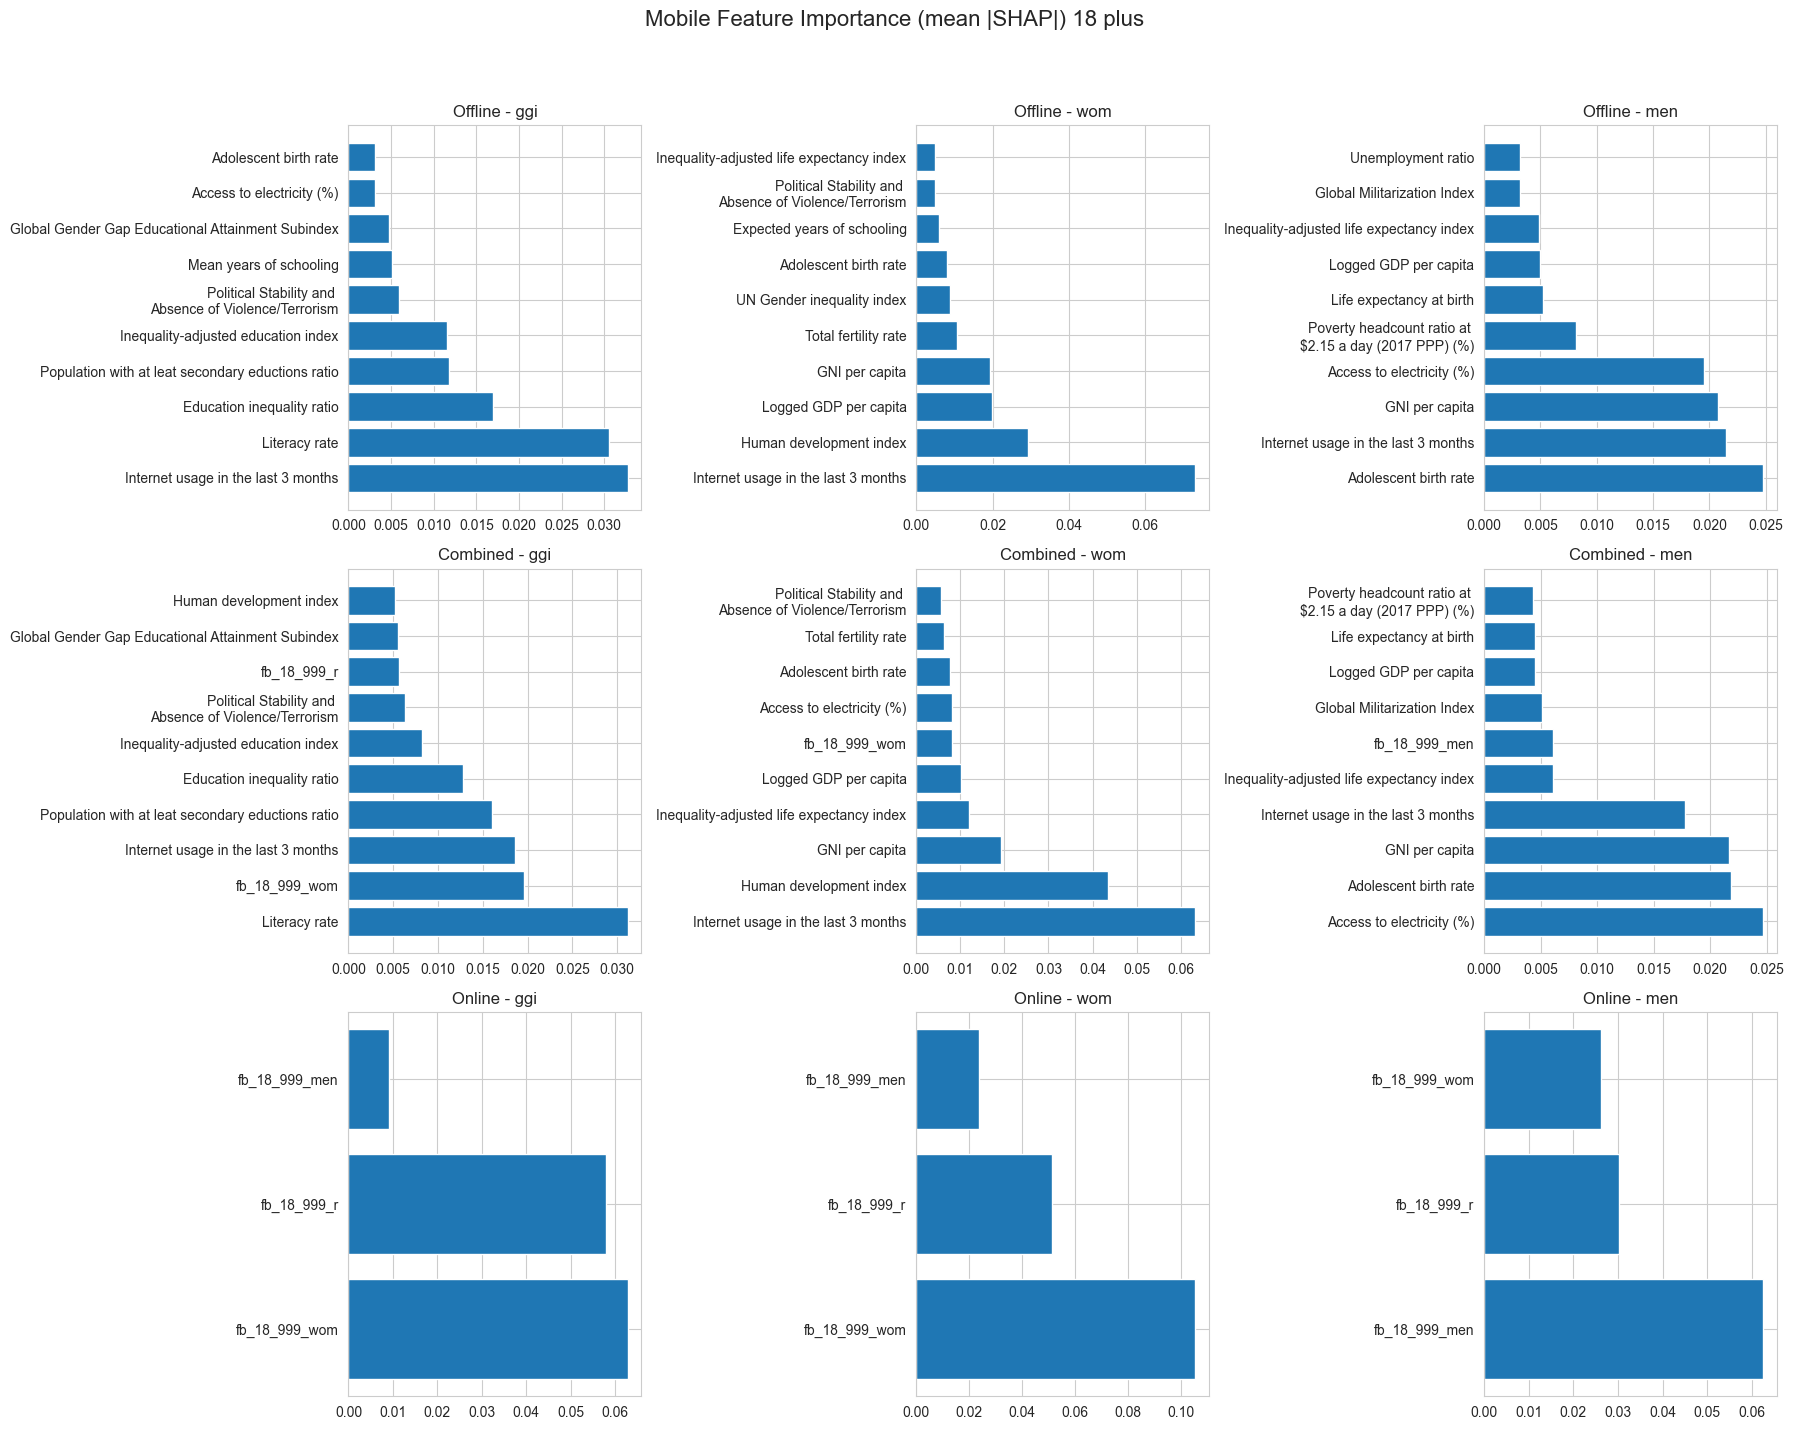

In [40]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Produce the file
model_folder = 'aggregate_paired_levels'
#model_folder = 'aggregate'
#model_folder = '18_plus_paired_levels'
# model_folder = '18_plus'
# model_folder = 'rf'
# model_folder = 'paired_levels'
# for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
for model_folder in ['18_plus']:
    dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
    top_n_features = 10
    # Import models and related dataset
    model_dict = {}
    indicators_to_plot = ['internet', 'mobile']
    
    for indicator in indicators_to_plot:
        data_path = params.dropbox_data_path / f"combined_data/{indicator}"
        model_dict[indicator] = {}
    
        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        fig.suptitle(f'{indicator.capitalize()} Feature Importance (mean |SHAP|) {model_folder.replace("_", " ").capitalize()}', fontsize=16)
        axes = axes.ravel()
    
        plot_idx = 0
        for model_type in ['offline', 'combined', 'online']:
            model_dict[indicator][model_type] = {}
            for outcome_var in ['ggi', 'wom', 'men']:
                model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
                model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
    
                model = load_model(model_filepath)
                model_dict[indicator][model_type][outcome_var] = model
                data = pd.read_csv(data_path / dataset)
                model_spec = model.feature_names_in_
                if model_type == 'offline':
                    print(indicator, model_type, model_spec)
    
                # Drop rows where the target variable is missing
                data = data.dropna(subset=[f'{indicator}_{outcome_var}'])
                data.rename(columns={f'{indicator}_year': 'year'}, inplace=True)
                
                """ 
                # Preprocess data
                conti_cols = [f'conti_{conti}' for conti in ['Asia', 'Africa', 'Europe', 'South America', 'North America', 'Oceania']]
                X = preprocess_data(data[list(set(model_spec) - set(conti_cols))])
                if any(conti_cols) in model_spec:
                    cols = [x for x in model_spec if 'conti' in x]
                    for col in cols:
                        X[col] = [0] * len(X)
                """
                # X = preprocess_data(data[model_spec])
                X = data[model_spec]
                y = data[f'{indicator}_{outcome_var}']
    
                # Computing SHAP
                # Using SHAP to compute feature importance
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X)
    
                # Compute mean absolute Shapley values to get feature importance
                feature_importance = np.abs(shap_values).mean(axis=0)
    
                sorted_idx = np.argsort(feature_importance)[::-1]
                pos = np.arange(sorted_idx.shape[0]) + .5
                pos = pos[0:top_n_features]
    
                # Plot feature importance using Shapley values
                ax = axes[plot_idx]
                ax.barh(pos, feature_importance[sorted_idx][0:top_n_features], align='center')
                ax.set_yticks(pos)
                ax.set_yticklabels([bg_col_dict[x] if x in bg_col_dict.keys() else x for x in model_spec[sorted_idx][0:top_n_features]])
                # ax.set_xlabel('Mean |SHAP|')
                ax.set_title(f'{model_type.capitalize()} - {outcome_var}')
    
                plot_idx += 1
    
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(params.dropbox_data_path.parent / f'graphs/feature_importance/{indicator}_{model_folder}_shap_values.pdf')
    

## Total Fertility Rate in Internet prediction by sub-region

here we select model_folder = 'aggregate_paired_levels' as the model specification to explore the difference in feature importance for the prediction of total fertility rate by sub-region

In [4]:
import shap

model_folder = 'aggregate'
indicator = 'internet' 
model_type = "combined"
outcome_var = 'ggi'

# read the model and SHAP values
dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
data_path = params.dropbox_data_path / f"combined_data/{indicator}"

model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename

model = load_model(model_filepath)
data = pd.read_csv(data_path / dataset)
model_spec = model.feature_names_in_
if model_type == 'offline':
    print(indicator, model_type, model_spec)

# Drop rows where the target variable is missing
data = data.dropna(subset=[f'{indicator}_{outcome_var}'])
data.rename(columns={f'{indicator}_year': 'year'}, inplace=True)
X = data[model_spec]
y = data[f'{indicator}_{outcome_var}']
    
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
pred_y = model.predict(X)
# Compute mean absolute Shapley values to get feature importance
feature_importance = np.abs(shap_values).mean(axis=0)


In [5]:
shap_values_abs = pd.DataFrame(np.abs(shap_values), columns=model_spec)
data.reset_index(drop=True, inplace=True)
shap_values_abs['iso3'] = data['iso3']
shap_values_abs['year'] = data['year']
shap_values_abs['continent'] = data['conti']

df_sub_region = pd.read_csv(params.dropbox_data_path.parent / 'files/definition_of_regions.csv',delimiter=';')
shap_values_abs = shap_values_abs.merge(df_sub_region[['ISO-alpha3 Code','Sub-region Name']],left_on='iso3',right_on='ISO-alpha3 Code',how='left')
shap_values_abs.rename(columns = {'Sub-region Name':'sub_region'},inplace=True)
    

Text(0.5, 1.0, 'Total Fertility Rate importance (mean |SHAP|) in Internet prediction by sub-region')

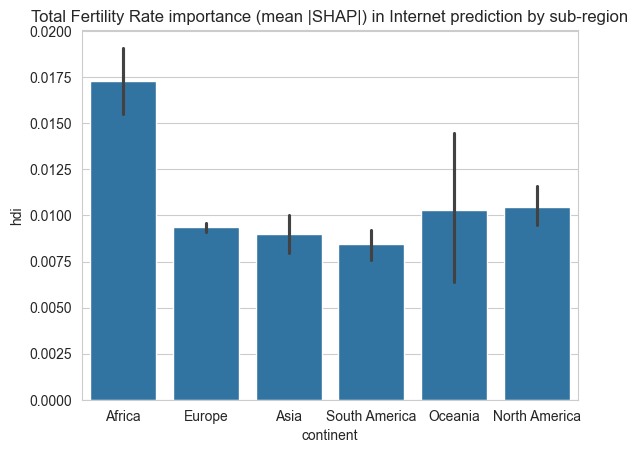

In [6]:
import seaborn as sns

sns.barplot(x='continent',y='hdi',data=shap_values_abs)
plt.title('Total Fertility Rate importance (mean |SHAP|) in Internet prediction by sub-region')

In [7]:
shap_values = pd.DataFrame(shap_values, columns=model_spec)
data.reset_index(drop=True, inplace=True)
shap_values['iso3'] = data['iso3']
shap_values['year'] = data['year']
shap_values['continent'] = data['conti']
shap_values['pred'] = pred_y


Text(0.5, 1.0, 'Total Fertility Rate importance in Internet prediction by country')

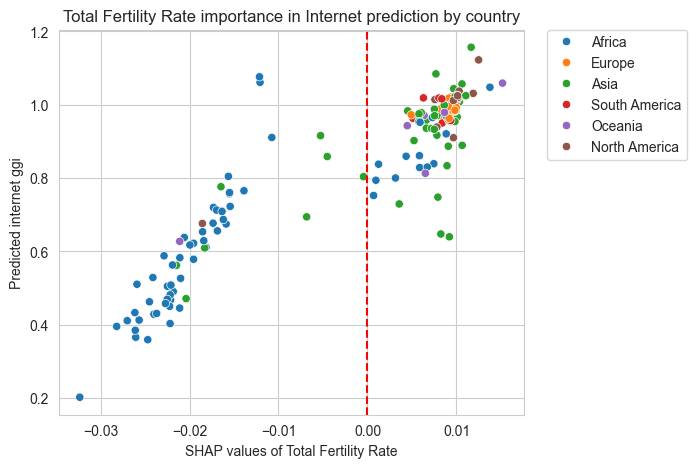

In [8]:
# by country 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(x='hdi',y='pred',hue = 'continent',data=shap_values,ax =ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.set_ylabel('Predicted internet ggi')
ax.set_xlabel('SHAP values of Total Fertility Rate')
ax.axvline(x=0,color = 'red',linestyle='--')
plt.title('Total Fertility Rate importance in Internet prediction by country')

# model errors  

## firstly save the betas from the linear models 

In [8]:
# leave one out validation to retrieve the pred and true values
def leave_one_column_out_for_error_estimation(column,data,X,y):
    
    recorder = pd.DataFrame(columns=["name", 'outcome_var', 'model_type', column, 'year', 'pred', 'true'])
    for unique_value in data[column].unique():
        X_test_loo = X[data[column] == unique_value]
        y_test_loo = y[data[column] == unique_value]
        
        years = data.loc[X_test_loo.index,'year'].tolist()
        # Check if a model for this specific validation already exists
        model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_{column}_{unique_value}_model.pkl'
        model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
        
        # load model 
        rf_loo = load_model(model_filepath)
        if rf_loo is None:
            raise ValueError(f"Model not found: {model_filepath}")

        y_pred_loo = rf_loo.predict(X_test_loo)
        for i in range(len(y_pred_loo)):
            recorder.loc[len(recorder)] = [f'{indicator} {model_type}', outcome_var, model_type, unique_value,years[i], y_pred_loo[i], y_test_loo.values[i]]

    r2 = r2_score(recorder['true'], recorder['pred'])
    mean_abs = np.abs(recorder['true'] - recorder['pred']).mean()
    return recorder, r2,mean_abs

In [9]:
from scipy.optimize import nnls
from sklearn.metrics import  r2_score

model_folder = '18_plus'
leave_column = 'country'
model_spec = params.bg_cols+['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
coef = pd.DataFrame(columns =['model','r2','mean_abs_diff']+list(model_spec)+['year'])

df_errors = pd.DataFrame()

dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
for indicator in ['internet', 'mobile']:
    data_path = params.dropbox_data_path / f"combined_data/{indicator}"
    # only combined model
    model_type='combined'
    for outcome_var in ['ggi', 'wom', 'men']:
        
         # read and preprocess the previous model data 
        data = pd.read_csv(data_path / dataset)
        data.rename(columns={f'{indicator}_year':'year'}, inplace=True)
        
        # prepare the data for error estimation 
        data = data.dropna(subset=model_spec) # important! remove countries with missing values in FB features 
        data = data.dropna(subset=[f'{indicator}_{outcome_var}'])
    
        # load full model to get the specs 
        model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
        
        # Try to load the model if it exists
        rf_loo = load_model(model_filepath)
        model_spec = rf_loo.feature_names_in_

        # preprocess data 
        X = data[model_spec]
        y = data[f'{indicator}_{outcome_var}']
        # store the true/pred values 
        df_res, r2, abs_mean_error = leave_one_column_out_for_error_estimation(leave_column,data,X,y)
        
        data = data.merge(df_res[['country','pred','true','year']],on=['country','year'],how='left')
        data.rename(columns={'pred':'predicted'},inplace=True)
         
        # calculate the absolute difference
        data['abs_diff'] = np.abs(data[f'{indicator}_{outcome_var}'] - data['predicted'])
        data = data[['iso3', 'country', 'year',f'{indicator}_{outcome_var}','predicted','abs_diff']+list(model_spec)]
        
        data['year']=data['year']/10000
        # now fit the model 
        model_name = f'{indicator}_{outcome_var}'
        # Perform non-negative linear regression
        coefficients, residual = nnls(data[list(model_spec)+['year']], data['abs_diff'])
        residual_pred = data[list(model_spec)+['year']] @ coefficients 
        
        data['predicted_error'] = residual_pred
        residual_r2= r2_score(data['abs_diff'],residual_pred)
        data = data[['iso3', 'country', 'year',f'{indicator}_{outcome_var}','predicted','abs_diff','predicted_error']]
        df_errors = pd.concat([df_errors,data],axis=0)
        abs_diff = data['abs_diff'].mean()
        print(abs_mean_error==abs_diff)
         
                
        new_row = {'model': model_name,'r2': residual_r2,'mean_abs_diff': abs_diff}
        coef_dict = dict(zip(list(model_spec)+['year'], coefficients)) 
        new_row.update(coef_dict)
        coef = coef.append(new_row, ignore_index=True)

# coef.to_csv(params.dropbox_data_path.parent / f'results/rf/{model_folder}{f"_{leave_column}" if len(leave_column)>0 else "" }_model_error_estimation_betas.csv',index=False)

True
True
True
True
True
True


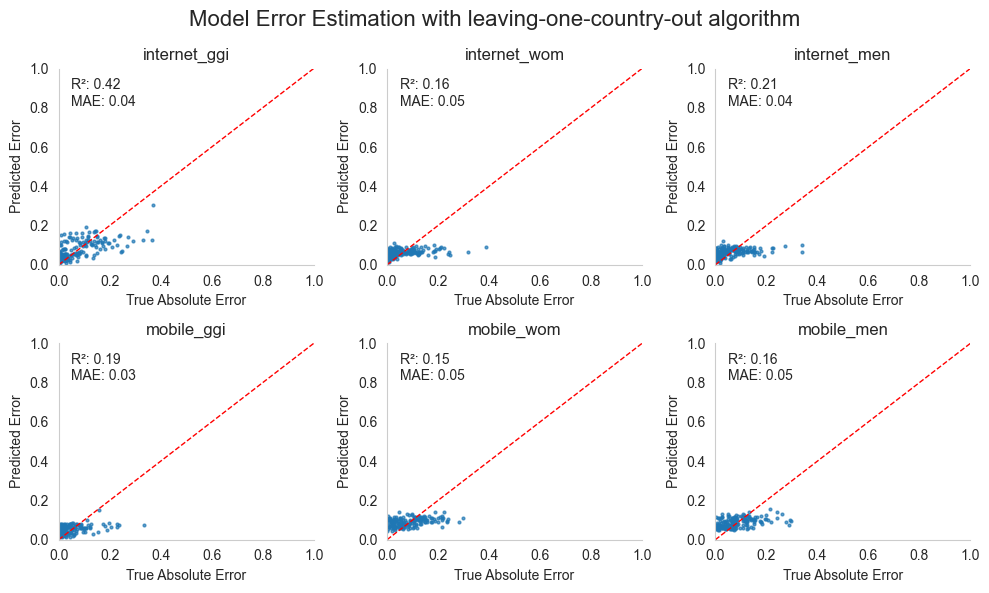

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

true_value_cols = ['internet_ggi', 'internet_wom', 'internet_men', 
                   'mobile_ggi', 'mobile_wom', 'mobile_men']

df_long = df_errors.melt(
    id_vars=['iso3', 'country', 'year', 'predicted', 'abs_diff', 'predicted_error'],
    value_vars=true_value_cols,
    var_name='outcome_var',
    value_name='true'
).dropna()

# Calculate R^2 and Absolute Mean Error for annotation
annotations = {}
for col in true_value_cols:
    subset = df_long[df_long['outcome_var'] == col]
    if not subset.empty:
        if len(subset) > 1:  # Ensure at least two points for R^2 calculation
            r2 = r2_score(subset['abs_diff'], subset['predicted_error'])
        else:
            r2 = np.nan  # Undefined for less than two points
        mae = mean_absolute_error(subset['abs_diff'], subset['predicted_error'])
        annotations[col] = {'r2': r2, 'mae': mae}

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()

# Plotting each outcome variable
for i, col in enumerate(true_value_cols):
    ax = axes[i]
    subset = df_long[df_long['outcome_var'] == col]
    if not subset.empty:
        ax.scatter(subset['abs_diff'], subset['predicted_error'], alpha=0.7,s=4)
        ax.set_title(col)
        ax.set_xlabel('True Absolute Error')
        ax.set_ylabel('Predicted Error')
        ax.set_xlim(0, 1)
        ax.set_ylim(0,1)
        ax.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
        ax.grid(alpha=0)
        # Add annotation
        if col in annotations:
            ax.text(0.05, 0.95, f"R²: {annotations[col]['r2']:.2f}\nMAE: {annotations[col]['mae']:.2f}",
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
        # set the top and right spine invisible 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
            
# Adjust layout
fig.suptitle('Model Error Estimation with leaving-one-country-out algorithm', fontsize=16)
plt.tight_layout()
plt.show()


## error from the full model 

In [18]:
model_spec = params.bg_cols+['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men'] 
print(model_spec)
model_spec = rf_loo.feature_names_in_
print(model_spec)


['abr', 'bicc_gmi', 'coef_ineq', 'eys', 'eys_r', 'gdi', 'gdp_pcap', 'gggi_eas', 'gggi_ggi', 'gggi_hss', 'gggi_pes', 'gggi_pos', 'gii', 'gni_pc', 'gni_pc_r', 'hcpi_a', 'hdi', 'hdi_r', 'ihdi', 'ineq_edu', 'ineq_inc', 'ineq_le', 'le', 'le_r', 'lfpr_r', 'mmr', 'mys', 'mys_r', 'pov_hr', 'se_r', 'une_girlglsr', 'une_girlglst', 'une_girlgpr', 'une_girlgpt', 'vdem_gender', 'wbgi_pve', 'wdi_acel', 'wdi_fertility', 'wdi_gert', 'wdi_gertr', 'wdi_litrad', 'wdi_litradr', 'pr_r', 'wdi_unemp', 'wdi_unempr', 'wdi_internet', 'educ_hdi_r', 'fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
['bicc_gmi' 'pr_r' 'gni_pc_r' 'hdi' 'gii' 'hcpi_a' 'gdp_pcap' 'wdi_gertr'
 'wdi_unempr' 'gggi_pos' 'pov_hr' 'gggi_pes' 'wdi_gert' 'wdi_acel' 'le_r'
 'abr' 'mys_r' 'se_r' 'wdi_litrad' 'une_girlgpt' 'lfpr_r' 'eys' 'gggi_ggi'
 'mmr' 'ineq_edu' 'ihdi' 'une_girlglsr' 'educ_hdi_r' 'mys' 'wdi_litradr'
 'gni_pc' 'une_girlgpr' 'gggi_eas' 'wdi_internet' 'gdi' 'coef_ineq'
 'gggi_hss' 'wbgi_pve' 'wdi_fertility' 'eys_r' 'une_girlgls

In [27]:
from scipy.optimize import nnls
from sklearn.metrics import  r2_score

model_folder = '18_plus'
leave_column=''
model_spec = params.bg_cols+['fb_18_999_r', 'fb_18_999_wom', 'fb_18_999_men']
coef = pd.DataFrame(columns =['model','r2','mean_abs_diff']+list(model_spec)+['year'])
df_errors = pd.DataFrame()

dataset = "combined_multiple_years_no_missing_keep_countries_fb_aligned.csv"
for indicator in ['internet', 'mobile']:
    data_path = params.dropbox_data_path / f"combined_data/{indicator}"
    # only combined model
    model_type='combined'
    for outcome_var in ['ggi', 'wom', 'men']:
                
        # read and preprocess the previous model data 
        data = pd.read_csv(data_path / dataset)
        data.rename(columns={f'{indicator}_year':'year'}, inplace=True)
        
        # load models 
        
        model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
        
        # Try to load the model if it exists
        rf_loo = load_model(model_filepath)
        model_spec = rf_loo.feature_names_in_
        # print(indicator,model_type,outcome_var,model_spec)
        
        # prepare the data for error estimation 
        data = data.dropna(subset=model_spec) # important! remove countries with missing values in FB features 
        data = data.dropna(subset=[f'{indicator}_{outcome_var}'])
        
        # preprocess data 
        X = data[model_spec]
        y = data[f'{indicator}_{outcome_var}']
        
        # get the predictions from rf
        pred_y = rf_loo.predict(X)
        data['predicted'] = pred_y
        
        # calculate the absolute difference
        data['abs_diff'] = np.abs(data[f'{indicator}_{outcome_var}'] - data['predicted'])
        data = data[['iso3', 'country', 'year',f'{indicator}_{outcome_var}','predicted','abs_diff']+list(model_spec)]
        
        data['year']=data['year']/10000
        # now fit the model 
        model_name = f'{indicator}_{outcome_var}'
        # Perform non-negative linear regression
        coefficients, residual = nnls(data[list(model_spec)+['year']], data['abs_diff'])
        residual_pred = data[list(model_spec)+['year']] @ coefficients 
        
        data['predicted_error'] = residual_pred
        residual_r2= r2_score(data['abs_diff'],residual_pred)
        data = data[['iso3', 'country', 'year',f'{indicator}_{outcome_var}','predicted','abs_diff','predicted_error']]
        df_errors = pd.concat([df_errors,data],axis=0)
        abs_diff = data['abs_diff'].mean()
        
        new_row = {'model': model_name,'r2': residual_r2,'mean_abs_diff': abs_diff}
        coef_dict = dict(zip(model_spec, coefficients)) 
        new_row.update(coef_dict)
        
        coef = coef.append(new_row, ignore_index=True)


coef.to_csv(params.dropbox_data_path.parent / f'results/rf/{model_folder}{f"_{leave_column}" if len(leave_column)>0 else "" }_model_error_estimation_betas_new.csv',index=False)

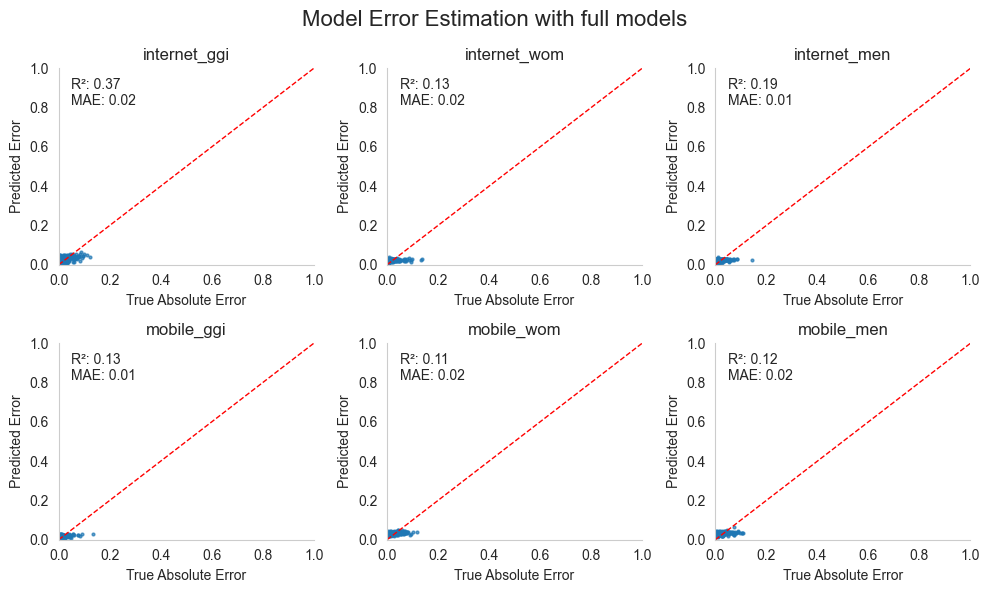

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

true_value_cols = ['internet_ggi', 'internet_wom', 'internet_men', 
                   'mobile_ggi', 'mobile_wom', 'mobile_men']

df_long = df_errors.melt(
    id_vars=['iso3', 'country', 'year', 'predicted', 'abs_diff', 'predicted_error'],
    value_vars=true_value_cols,
    var_name='outcome_var',
    value_name='true'
).dropna()

# Calculate R^2 and Absolute Mean Error for annotation
annotations = {}
for col in true_value_cols:
    subset = df_long[df_long['outcome_var'] == col]
    if not subset.empty:
        if len(subset) > 1:  # Ensure at least two points for R^2 calculation
            r2 = r2_score(subset['abs_diff'], subset['predicted_error'])
        else:
            r2 = np.nan  # Undefined for less than two points
        mae = mean_absolute_error(subset['abs_diff'], subset['predicted_error'])
        annotations[col] = {'r2': r2, 'mae': mae}

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()

# Plotting each outcome variable
for i, col in enumerate(true_value_cols):
    ax = axes[i]
    subset = df_long[df_long['outcome_var'] == col]
    if not subset.empty:
        ax.scatter(subset['abs_diff'], subset['predicted_error'], alpha=0.7,s=4)
        ax.set_title(col)
        ax.set_xlabel('True Absolute Error')
        ax.set_ylabel('Predicted Error')
        ax.set_xlim(0, 1)
        ax.set_ylim(0,1)
        ax.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
        ax.grid(alpha=0)
        # Add annotation
        if col in annotations:
            ax.text(0.05, 0.95, f"R²: {annotations[col]['r2']:.2f}\nMAE: {annotations[col]['mae']:.2f}",
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
        # set the top and right spine invisible 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
            
# Adjust layout
fig.suptitle('Model Error Estimation with full models', fontsize=16)
plt.tight_layout()
plt.show()


# check one country

In [56]:
import os 
files = [x for x in os.listdir("/Users/valler/Dropbox/dgg_research/national/data_refresh/new_national_pipeline_files/results/pred_by_year_data/18_plus/combined") if '.csv' in x]
df= pd.DataFrame()
for file in files:
    df = pd.concat([df,pd.read_csv(f"/Users/valler/Dropbox/dgg_research/national/data_refresh/new_national_pipeline_files/results/pred_by_year_data/18_plus/combined/{file}")],axis=0)
df = df.loc[df['iso3']=='CHN',]

df['outcome_varname'] =df['indicator']+ '_'+df['outcome_var']


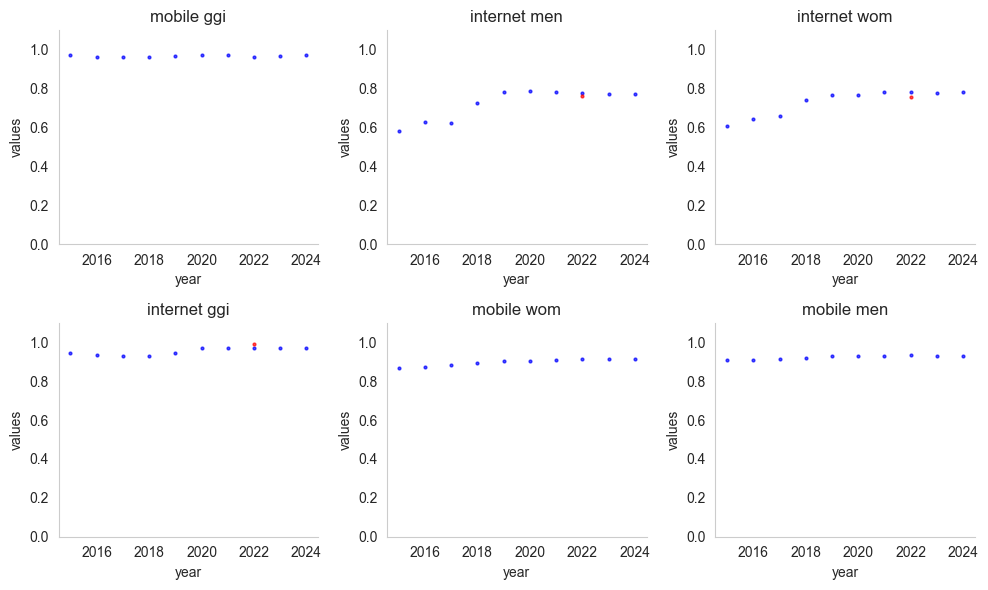

In [62]:

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()

# Plotting each outcome variable
for i, col in enumerate(df['outcome_varname'].unique()):
    ax = axes[i]
    subset = df[df['outcome_varname'] == col]
    if not subset.empty:
        ax.scatter(subset['year'], subset['pred'], alpha=0.7,s=4,label='Predicted',color='blue')
        ax.scatter(subset['year'], subset['true'], alpha=0.7,s=4,label='True',color='red')
        ax.set_title(col.replace('_',' '))
        ax.set_xlabel('year')
        ax.set_ylabel('values')
  
        ax.set_ylim(0,1.1)
        ax.grid(alpha=0)
        
        # set the top and right spine invisible 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
fig.tight_layout()
